In [34]:
akshit = '\u0905\u0915\u094D\u0937\u093F\u0924'
kotnala = '\u0915\u094B\u091F\u0928\u093E\u0932\u093E'
print(akshit, kotnala)


अक्षित कोटनाला


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import csv
import networkx as nx
import seaborn as sns
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

In [27]:
df = pd.read_csv("Market_Basket_Optimisation.csv", header = None)

In [28]:
df


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil
1,burgers,meatballs,eggs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,chutney,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,turkey,avocado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,mineral water,milk,energy bar,whole wheat rice,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7496,butter,light mayo,fresh bread,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7497,burgers,frozen vegetables,eggs,french fries,magazines,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7498,chicken,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7499,escalope,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
trans=[]
for i in range(0,df.shape[0]):
    a=[str(item) for item in df.iloc[i] if str(item) !='nan']
    trans.append(a)
trans[:5]   

[['shrimp',
  'almonds',
  'avocado',
  'vegetables mix',
  'green grapes',
  'whole weat flour',
  'yams',
  'cottage cheese',
  'energy drink',
  'tomato juice',
  'low fat yogurt',
  'green tea',
  'honey',
  'salad',
  'mineral water',
  'salmon',
  'antioxydant juice',
  'frozen smoothie',
  'spinach',
  'olive oil'],
 ['burgers', 'meatballs', 'eggs'],
 ['chutney'],
 ['turkey', 'avocado'],
 ['mineral water', 'milk', 'energy bar', 'whole wheat rice', 'green tea']]

In [30]:
te = TransactionEncoder()

te_ary = te.fit(trans).transform(trans)
df = pd.DataFrame(te_ary, columns=te.columns_)

feqi = apriori(df,min_support=0.03 , use_colnames=True)

rules = association_rules(feqi,metric="confidence",min_threshold=0.3)

# Filter the frequent itemsets to only those with 2 items (pairs)
pair_frequent_itemsets = feqi[feqi['itemsets'].apply(lambda x: len(x) == 2)]

# Print only the pairs
print(pair_frequent_itemsets)




rules


     support                            itemsets
36  0.033196                   (eggs, chocolate)
37  0.034395           (chocolate, french fries)
38  0.032129                   (chocolate, milk)
39  0.052660          (mineral water, chocolate)
40  0.039195              (spaghetti, chocolate)
41  0.036395                (eggs, french fries)
42  0.030796                        (eggs, milk)
43  0.050927               (mineral water, eggs)
44  0.036528                   (spaghetti, eggs)
45  0.033729       (mineral water, french fries)
46  0.035729  (mineral water, frozen vegetables)
47  0.031063          (mineral water, green tea)
48  0.040928        (mineral water, ground beef)
49  0.039195            (spaghetti, ground beef)
50  0.047994               (mineral water, milk)
51  0.035462                   (spaghetti, milk)
52  0.033729           (mineral water, pancakes)
53  0.059725          (mineral water, spaghetti)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
0,(chocolate),(mineral water),0.163845,0.238368,0.052660,0.321400,1.348332,0.013604,1.122357,0.308965
1,(frozen vegetables),(mineral water),0.095321,0.238368,0.035729,0.374825,1.572463,0.013007,1.218270,0.402413
2,(ground beef),(mineral water),0.098254,0.238368,0.040928,0.416554,1.747522,0.017507,1.305401,0.474369
3,(ground beef),(spaghetti),0.098254,0.174110,0.039195,0.398915,2.291162,0.022088,1.373997,0.624943
4,(milk),(mineral water),0.129583,0.238368,0.047994,0.370370,1.553774,0.017105,1.209650,0.409465
5,(pancakes),(mineral water),0.095054,0.238368,0.033729,0.354839,1.488616,0.011071,1.180529,0.362712
6,(spaghetti),(mineral water),0.174110,0.238368,0.059725,0.343032,1.439085,0.018223,1.159314,0.369437


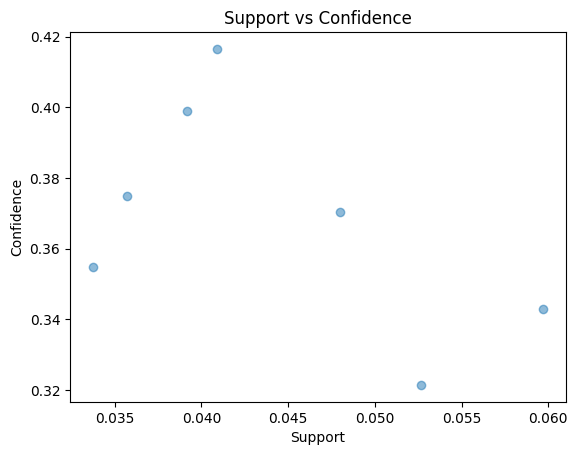

In [32]:
plt.scatter(rules['support'],rules['confidence'],alpha=0.5)
plt.title('Support vs Confidence')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.show()

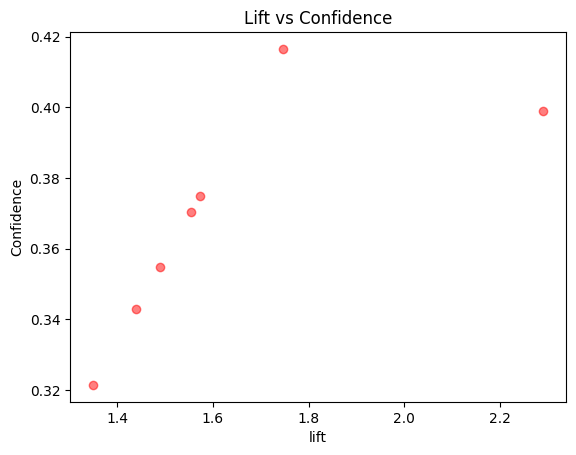

In [16]:
plt.scatter(rules['lift'],rules['confidence'] ,alpha = 0.5 , color='red')
plt.title('Lift vs Confidence')
plt.xlabel('lift')
plt.ylabel('Confidence')
plt.show()

In [33]:
rules_h_c = association_rules(feqi,metric="confidence",min_threshold=0.5)

rules_h_c.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric


In [7]:
# Apply the Apriori algorithm to find frequent itemsets using the one-hot encoded DataFrame
freq_itemset = apriori(df_encoded, min_support=0.03, use_colnames=True)

# Display the frequent itemsets
print(freq_itemset)


     support                            itemsets
0   0.033329                           (avocado)
1   0.033729                          (brownies)
2   0.087188                           (burgers)
3   0.030129                            (butter)
4   0.081056                              (cake)
5   0.046794                         (champagne)
6   0.059992                           (chicken)
7   0.163845                         (chocolate)
8   0.080389                           (cookies)
9   0.051060                       (cooking oil)
10  0.031862                    (cottage cheese)
11  0.179709                              (eggs)
12  0.079323                          (escalope)
13  0.170911                      (french fries)
14  0.043061                       (fresh bread)
15  0.063325                   (frozen smoothie)
16  0.095321                 (frozen vegetables)
17  0.052393                     (grated cheese)
18  0.132116                         (green tea)
19  0.098254        

In [8]:
rules = association_rules(freq_itemset, metric = 'confidence', min_threshold = 0.2)
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
0,(chocolate),(eggs),0.163845,0.179709,0.033196,0.202604,1.127397,0.003751,1.028711,0.135143
1,(french fries),(chocolate),0.170911,0.163845,0.034395,0.201248,1.228284,0.006393,1.046827,0.224169
2,(chocolate),(french fries),0.163845,0.170911,0.034395,0.209927,1.228284,0.006393,1.049383,0.222275
3,(milk),(chocolate),0.129583,0.163845,0.032129,0.247942,1.513276,0.010898,1.111823,0.389677
4,(mineral water),(chocolate),0.238368,0.163845,0.052660,0.220917,1.348332,0.013604,1.073256,0.339197
5,(chocolate),(mineral water),0.163845,0.238368,0.052660,0.321400,1.348332,0.013604,1.122357,0.308965
6,(spaghetti),(chocolate),0.174110,0.163845,0.039195,0.225115,1.373952,0.010668,1.079070,0.329550
7,(chocolate),(spaghetti),0.163845,0.174110,0.039195,0.239219,1.373952,0.010668,1.085581,0.325505
8,(eggs),(french fries),0.179709,0.170911,0.036395,0.202522,1.184961,0.005681,1.039640,0.190286
9,(french fries),(eggs),0.170911,0.179709,0.036395,0.212949,1.184961,0.005681,1.042232,0.188267


In [15]:
# Add lift and conviction
rules['lift'] = rules['confidence'] / rules['consequents'].map(df_encoded.sum() / len(df_encoded))
rules['conviction'] = (1 - rules['consequents'].map(df_encoded.sum() / len(df_encoded))) / (1 - rules['confidence'])
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift', 'conviction']])


            antecedents      consequents   support  confidence  lift  \
0           (chocolate)           (eggs)  0.033196    0.202604   NaN   
1        (french fries)      (chocolate)  0.034395    0.201248   NaN   
2           (chocolate)   (french fries)  0.034395    0.209927   NaN   
3                (milk)      (chocolate)  0.032129    0.247942   NaN   
4       (mineral water)      (chocolate)  0.052660    0.220917   NaN   
5           (chocolate)  (mineral water)  0.052660    0.321400   NaN   
6           (spaghetti)      (chocolate)  0.039195    0.225115   NaN   
7           (chocolate)      (spaghetti)  0.039195    0.239219   NaN   
8                (eggs)   (french fries)  0.036395    0.202522   NaN   
9        (french fries)           (eggs)  0.036395    0.212949   NaN   
10               (milk)           (eggs)  0.030796    0.237654   NaN   
11               (eggs)  (mineral water)  0.050927    0.283383   NaN   
12      (mineral water)           (eggs)  0.050927    0.213647  

C:\Users\akshi\AppData\Local\Temp\ipykernel_32880\1655869927.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Lift')


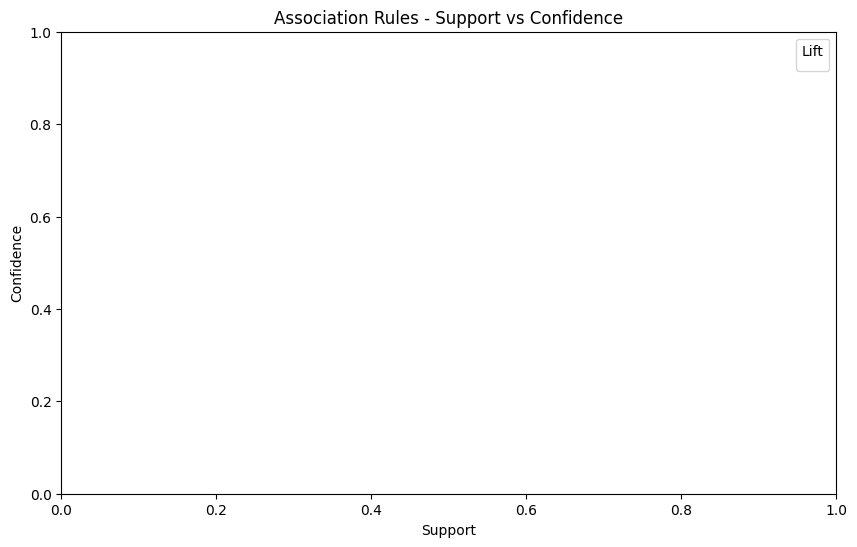

In [16]:
# Visualize the rules
plt.figure(figsize=(10, 6))
sns.scatterplot(x='support', y='confidence', data=rules, hue='lift', size='lift', sizes=(20, 200), alpha=0.6)
plt.title('Association Rules - Support vs Confidence')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.legend(title='Lift')
plt.show()

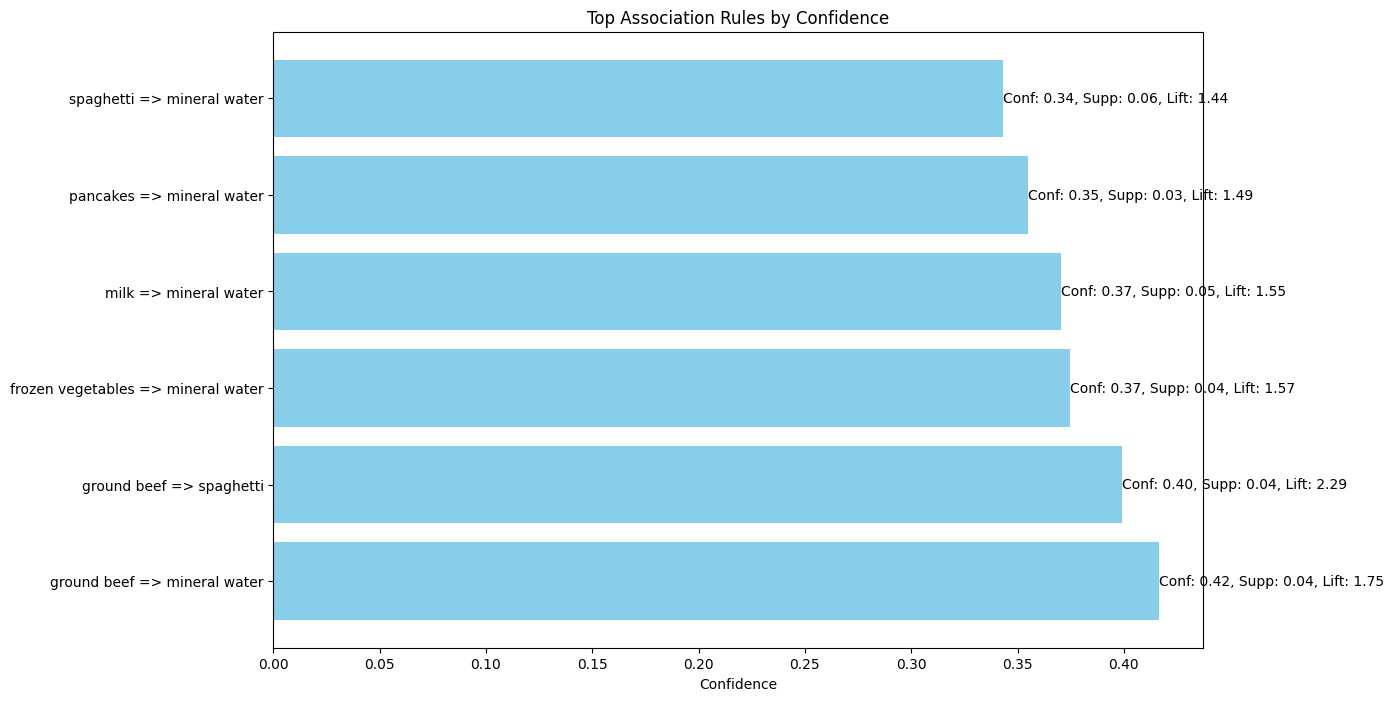

In [10]:
# Sorting rules by confidence
rules_sorted = rules.sort_values(by='confidence', ascending=False)

# Selecting top rules
top_rules = rules_sorted.head(6)

# Plotting
plt.figure(figsize=(12, 8))

# Creating a horizontal bar chart
plt.barh(
    top_rules['antecedents'].apply(lambda x: ', '.join(x)) + ' => ' + top_rules['consequents'].apply(lambda x: ', '.join(x)),
    top_rules['confidence'], color='skyblue'
)

# Adding annotations for support and lift
for index, value in enumerate(top_rules['confidence']):
    plt.text(value, index, f'Conf: {value:.2f}, Supp: {top_rules["support"].iloc[index]:.2f}, Lift: {top_rules["lift"].iloc[index]:.2f}', va='center')

plt.xlabel('Confidence')
plt.title('Top Association Rules by Confidence')
plt.show()



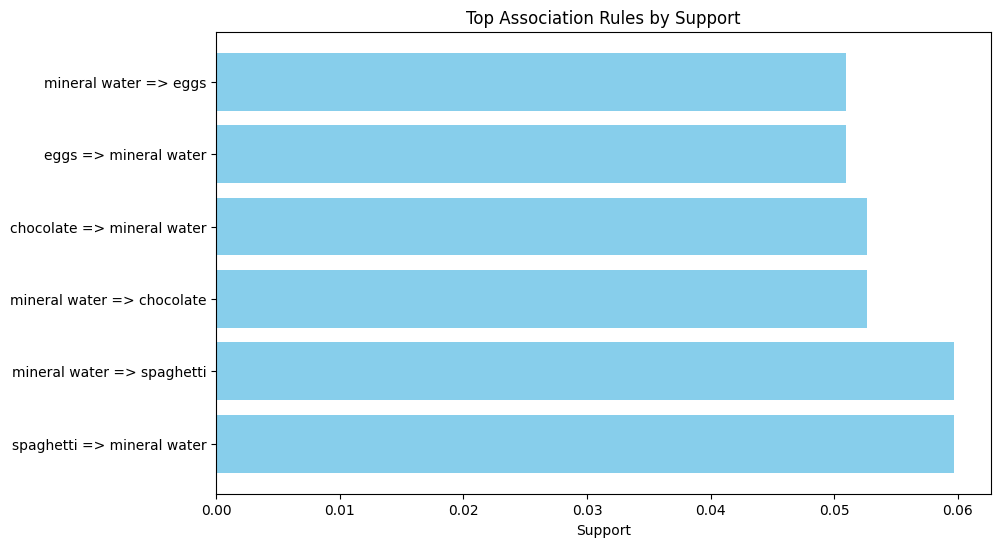

In [11]:
rules_sorted = rules.sort_values(by='support', ascending=False)

# Select top rules based on support
top_rules = rules_sorted.head(6)

plt.figure(figsize=(10, 6))
plt.barh(
    top_rules['antecedents'].apply(lambda x: ', '.join(x)) + ' => ' + top_rules['consequents'].apply(lambda x: ', '.join(x)),
    top_rules['support'], color='skyblue'
)

plt.xlabel('Support')
plt.title('Top Association Rules by Support')
plt.show()


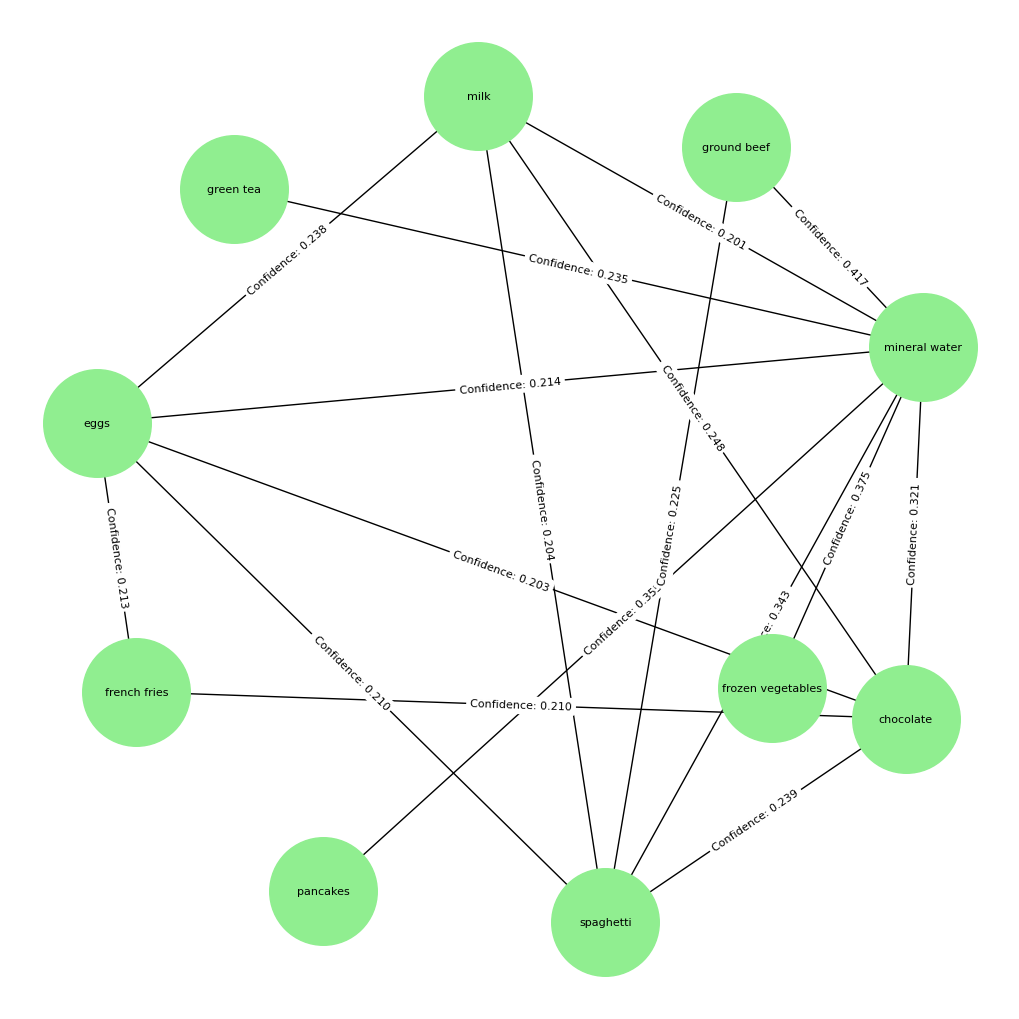

In [12]:
G = nx.Graph()

# GRAPH OF CONFIDENCE
for i, rule in rules.iterrows():
    antecedents = ", ".join(rule['antecedents'])
    consequents = ", ".join(rule['consequents'])
    rule_name = f"{antecedents} -> {consequents}"
    confidence = rule['confidence']

    G.add_node(antecedents, label=antecedents)
    G.add_node(consequents, label=consequents)
    G.add_edge(antecedents, consequents, label=f"Confidence: {confidence:.3f}")

# LABELLING
labels = {node: G.nodes[node]['label'] for node in G.nodes}
edge_labels = {edge: G.edges[edge]['label'] for edge in G.edges}

plt.figure(figsize=(10, 10))
pos = nx.spring_layout(G, k=15)

nx.draw(G, pos, labels=labels, node_size=6000, font_size=8, node_color='lightgreen', with_labels=True)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
plt.axis('off')
plt.show()

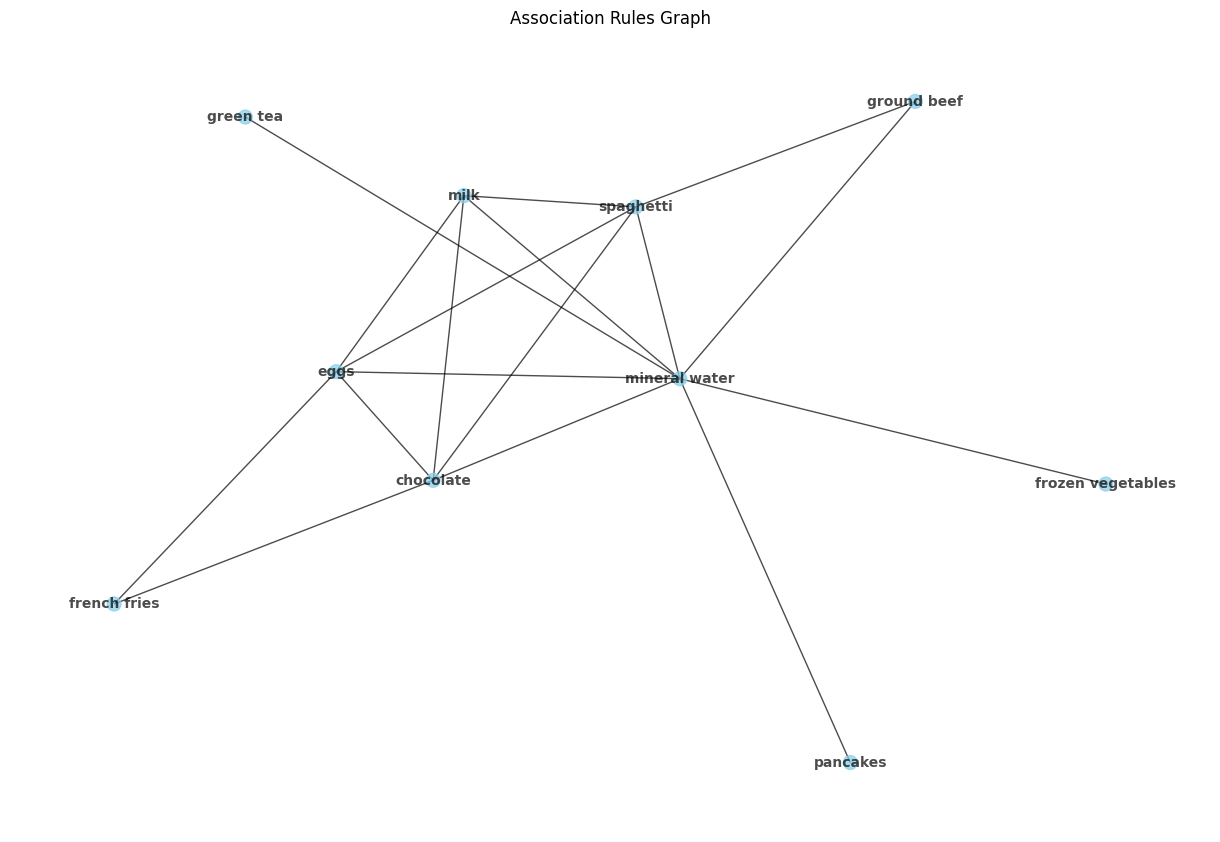

In [13]:
# Create a new graph
G = nx.Graph()

# Add nodes and edges to the graph
for i, rule in rules.iterrows():
    a = ", ".join(rule['antecedents'])
    b = ", ".join(rule['consequents'])
    G.add_node(a, size=1000)  # Node size can be adjusted
    G.add_node(b, size=1000)
    G.add_edge(a, b)

# Get node sizes based on support
node_sizes = [100 * (rules[rules['antecedents'] == set(node)]['support'].values[0] if node in rules['antecedents'].values else 1) for node in G.nodes()]

# Draw the graph
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G)  # Layout for positioning the nodes
nx.draw(G, pos, with_labels=True, node_size=node_sizes, node_color='skyblue', font_size=10, font_weight='bold', alpha=0.7)
plt.title('Association Rules Graph')
plt.show()